# Tranfer Learning VGG16 Chapter 10 Workshop 1

## Load module

In [73]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

from tensorflow.keras.preprocessing.image import ImageDataGenerator


## Declare variable

In [74]:
target_img_shape = (224, 224)

train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\train_set'
test_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\test_set'
val_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\val_set'

# Define process input for VGG
# train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Define process input for VGG with Data Augmentation
train_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

train_set = train_datagen.flow_from_directory(train_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')


val_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

val_set = val_datagen.flow_from_directory(val_dir,
                                                  target_size=target_img_shape,
                                                  batch_size=32,
                                                  class_mode='binary')

Found 15997 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


## Check data_set

In [75]:
batch = next(train_set) # train_set.next()
print(batch[0].shape)
print(batch[1].shape)

(32, 224, 224, 3)
(32,)


[0 0 0 ... 1 1 1]
(32, 224, 224, 3)
(32,)
['dog', 'cat', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat', 'dog', 'dog', 'dog']
-119.63594 130.91626


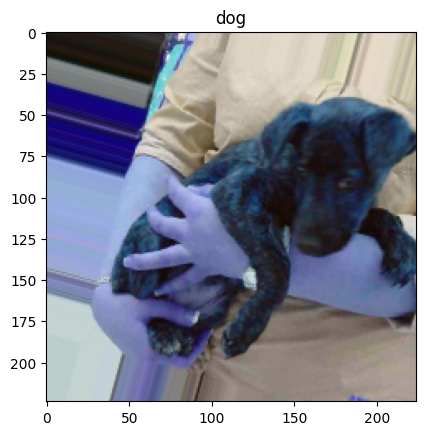

In [76]:
print(train_set.labels)
labels = train_set.class_indices
labels = {v: k for k, v in labels.items()} # dict((v, k) for k, v in labels_batch[0].items())

for image_batch, labels_batch in train_set:
    print(image_batch.shape)
    print(labels_batch.shape)
    
    labels_batch =  list(map(lambda x: labels[x], labels_batch))
    print(labels_batch)

    img = image_batch[0] - np.min(image_batch[0])
    img = img / np.max(img)

    print(np.min(image_batch[0]), np.max(image_batch[0]))
    plt.imshow(img)
    plt.title(labels_batch[0])
    
    break

In [77]:
ids, counts = np.unique(train_set.classes, return_counts=True)
print(ids)
print(counts)

[0 1]
[7997 8000]


In [78]:
for i in ids:
    print(labels[i], counts[i])

cat 7997
dog 8000


## Create model

### Create base model

In [79]:
in_shape = (target_img_shape[0], target_img_shape[1], 3)
in_shape

(224, 224, 3)

#### base model from VGG16 instance

In [80]:
base_model = VGG16(weights='imagenet', 
                   include_top=False, 
                   input_shape=in_shape)
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#### base model from saved model

In [81]:
from tensorflow.keras.models import Model, load_model

# Load the full VGG16 model (with top layers)
raw_model = load_model('./model/vgg16_model.h5')

# Inspect the layers (optional)
for i, layer in enumerate(raw_model.layers):
    print(i, layer.name)

# Get the last layer of the convolutional base
# For VGG16, this is usually 'block5_pool'
conv_base_output = raw_model.get_layer('block5_pool').output

# Create a new model with the same input but truncated after the conv base
base_model_from_raw = Model(inputs=raw_model.input, outputs=conv_base_output)

# Now base_model_from_raw behaves like base_model1
base_model_from_raw.summary()

0 input_layer_1
1 block1_conv1
2 block1_conv2
3 block1_pool
4 block2_conv1
5 block2_conv2
6 block2_pool
7 block3_conv1
8 block3_conv2
9 block3_conv3
10 block3_pool
11 block4_conv1
12 block4_conv2
13 block4_conv3
14 block4_pool
15 block5_conv1
16 block5_conv2
17 block5_conv3
18 block5_pool
19 flatten
20 fc1
21 fc2
22 predictions


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Combine base model with new top

In [82]:
model = Sequential()

model.add(base_model_from_raw) # 
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_25 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 17,926,209 (68.38 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
for layer in model.layers:
    print(layer.name, layer.trainable)

functional_25 True
flatten_7 True
dense_14 True
dense_15 True


### Freeze Feature Extraction layer

In [86]:
base_model_from_raw.trainable = False

In [88]:
print("Trainable..\n---")
for var in model.trainable_variables:
    print(var.name)

model.summary()

Trainable..
---
kernel
bias
kernel
bias


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_25 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile model

In [89]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train model

In [90]:
import time

es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)
mc = ModelCheckpoint('model/best_tranfer_vgg16_model.h5',
                       monitor='val_accuracy',
                       save_best_only=True,
                       verbose=1)

start = time.time()
history = model.fit(train_set,
                    steps_per_epoch=len(train_set),
                    epochs=20,
                    validation_data=val_set,
                    callbacks=[es, mc],
                    verbose=1
                    )

end = time.time()

print("Training time: ", round(end - start)/60, 2, "minites")


d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9423 - loss: 1.0583
Epoch 1: val_accuracy improved from -inf to 0.95550, saving model to model/best_tranfer_vgg16_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 546s 1s/step - accuracy: 0.9423 - loss: 1.0572 - val_accuracy: 0.9555 - val_loss: 0.0937
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.9742 - loss: 0.0750
Epoch 2: val_accuracy improved from 0.95550 to 0.96550, saving model to model/best_tranfer_vgg16_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.9742 - loss: 0.0750 - val_accuracy: 0.9655 - val_loss: 0.1311
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.9764 - loss: 0.0673
Epoch 3: val_accuracy improved from 0.96550 to 0.98250, saving model to model/best_tranfer_vgg16_model.h5


500/500 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.9764 - loss: 0.0673 - val_accuracy: 0.9825 - val_loss: 0.0678
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.9806 - loss: 0.0605
Epoch 4: val_accuracy did not improve from 0.98250
500/500 ━━━━━━━━━━━━━━━━━━━━ 498s 997ms/step - accuracy: 0.9805 - loss: 0.0605 - val_accuracy: 0.9770 - val_loss: 0.0611
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.9832 - loss: 0.0499
Epoch 5: val_accuracy did not improve from 0.98250
500/500 ━━━━━━━━━━━━━━━━━━━━ 484s 968ms/step - accuracy: 0.9832 - loss: 0.0499 - val_accuracy: 0.9775 - val_loss: 0.0711
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.9829 - loss: 0.0491
Epoch 6: val_accuracy did not improve from 0.98250
500/500 ━━━━━━━━━━━━━━━━━━━━ 483s 966ms/step - accuracy: 0.9829 - loss: 0.0491 - val_accuracy: 0.9780 - val_loss: 0.0631
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.9825 - loss: 0.0451
Epoch 7: val_a

KeyboardInterrupt: 